<a href="https://colab.research.google.com/github/fadeeva/Bayesian_Statistics_and_Quantitative_Finance/blob/main/01_Bayesian_estimation_of_volatility_with_unknown_drift/Bayesian_estimation_of_volatility_with_unknown_drift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import datetime as dt
import yfinance as yf

import arviz as az
import pymc as pm

import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Bayesian estimation of volatility with unknown drift

## Data

In [2]:
ticker = '^GSPC'
start = dt.datetime(2023, 1, 1)
interval = '1d'
data = yf.download(ticker, start=start, interval=interval, auto_adjust=True)
data.to_csv('data.csv')

[*********************100%***********************]  1 of 1 completed


In [3]:
df = pd.read_csv('data.csv', parse_dates=True, header=[0,1], index_col=0)
df.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2023-01-03,3824.139893,3878.459961,3794.330078,3853.290039,3959140000
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000


In [ ]:
df.shape

(834, 5)

In [4]:
df['log_return'] = np.log(df['Close'].div(df['Close'].shift(1)))
df.dropna(axis=0, inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,log_return
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,
Date,,,,,,
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000,0.007511
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000,-0.011714
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000,0.022584
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000,-0.000768
2023-01-10,3919.250000,3919.830078,3877.290039,3888.570068,3851030000,0.006954


In [ ]:
df.shape

(833, 6)

## Classical volatility estimation

In [ ]:
df['log_return'].std()

0.009415452073096025

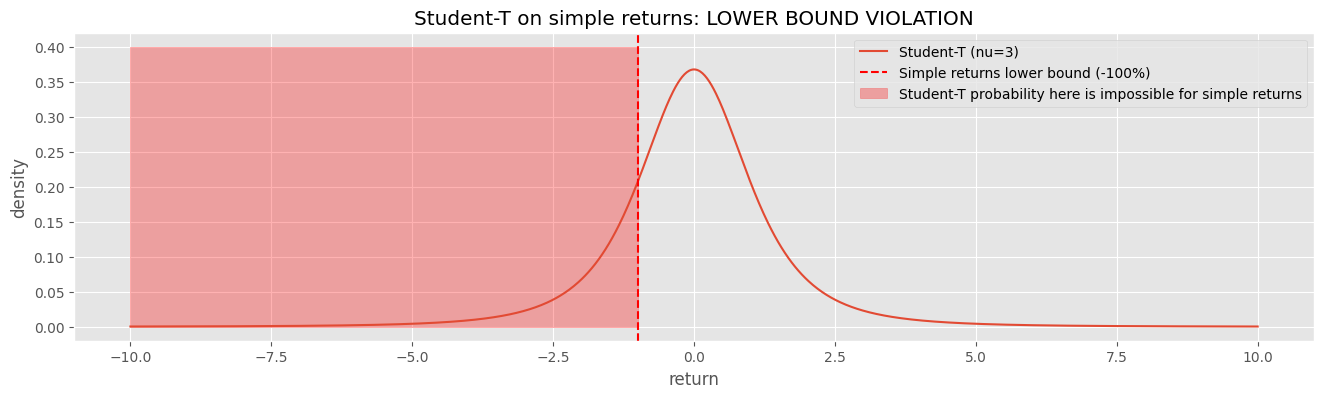

In [5]:
# Почему нужен log_return

from scipy.stats import t

# Студент-T определён на всей числовой прямой (−∞,+∞)
x = np.linspace(-10, 10, 1000)
plt.figure(figsize=(16, 4))
plt.plot(x, t.pdf(x, df=3), label='Student-T (nu=3)')

# Простые доходности ограничены снизу -1
plt.axvline(x=-1, color='r', linestyle='--', label='Simple returns lower bound (-100%)')
plt.fill_between([-10, -1], 0, 0.4, color='r', alpha=0.3, label='Student-T probability here is impossible for simple returns')

plt.xlabel('return')
plt.ylabel('density')
plt.title('Student-T on simple returns: LOWER BOUND VIOLATION')
plt.legend()

## Bayesian Estimation

### Normal Distribution

In [49]:
with pm.Model() as normal_model:
    mu = pm.Normal('mu', mu=0, sigma=0.01)
    sigma = pm.HalfNormal('b', sigma=0.02)

    returns_obs = pm.Normal('returns_obs', mu=mu, sigma=sigma, observed=df['log_return'])

    trace = pm.sample(2000, tune=1000, chains=4, return_inferencedata=True)

### Laplace's Distribution

In [50]:
with pm.Model() as laplace_model:
    mu = pm.Normal('mu', mu=0, sigma=0.01)
    b = pm.HalfNormal('b', sigma=0.02)  # scale parameter

    returns_obs = pm.Laplace('returns_obs', mu=mu, b=b, observed=df['log_return'])

    trace = pm.sample(2000, tune=1000, chains=4, return_inferencedata=True)

In [21]:
b_samples = trace.posterior['b'].values.flatten()

In [24]:
laplace_samples = b_samples * np.sqrt(2) # daily

In [32]:
len(student_samples), len(laplace_samples)

(8000, 8000)

### Student Distribution

In [51]:
with pm.Model() as student_model:
    mu = pm.Normal('mu', mu=0, sigma=.01) # drift
    sigma = pm.HalfNormal('sigma', sigma=.05) # volatility
    nu = pm.Gamma("nu", alpha=2, beta=0.1)  # degrees of freedom, tail thickness

    returns = pm.StudentT('returns', mu=mu, sigma=sigma, nu=nu, observed=df['log_return'])

    trace = pm.sample(2000, tune=1000, chains=4, return_inferencedata=True)

az.plot_trace(trace)

In [26]:
summary = az.summary(trace, hdi_prob=0.94)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.001,0.000,0.001,0.002,0.000,0.00,6094.0,5435.0,1.0
nu,4.425,0.713,3.246,5.826,0.011,0.01,4270.0,5185.0,1.0
sigma,0.007,0.000,0.006,0.007,0.000,0.00,4484.0,5348.0,1.0


In [ ]:
list(trace.posterior.data_vars)

['mu', 'nu', 'sigma']

In [30]:
mu_samples = trace.posterior['mu'].values.flatten()
sigma_samples = trace.posterior['sigma'].values.flatten()
nu_samples = trace.posterior['nu'].values.flatten()

In [31]:
# Корректировка: true volatility = sigma * sqrt(nu/(nu-2))
# Защита от nu <= 2 (иначе бесконечная дисперсия)
nu_safe = np.maximum(nu_samples, 2.01)
student_samples = sigma_samples * np.sqrt(nu_safe / (nu_safe - 2))

### Result

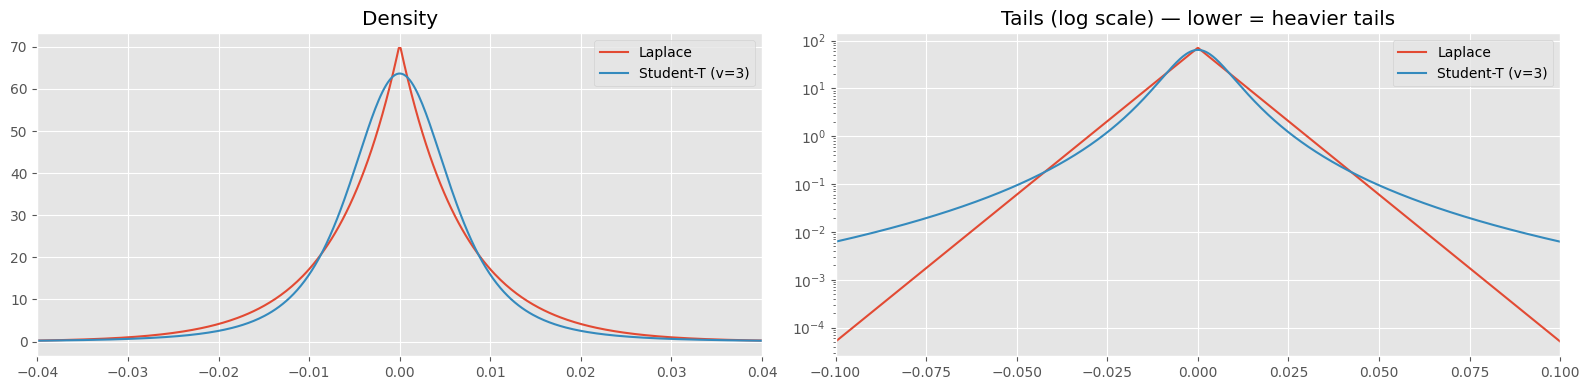

In [46]:
from scipy.stats import t, laplace, norm

# Параметры, чтобы все распределения имели одинаковую волатильность (std = 0.01)
target_std = 0.01

# Normal: sigma = 0.01
norm_sigma = 0.01

# Laplace: b = sigma / sqrt(2) = 0.01 / 1.414 = 0.00707
laplace_b = target_std / np.sqrt(2)

# Student-T: sigma = target_std / sqrt(nu/(nu-2))
nu = 3
student_sigma = target_std / np.sqrt(nu/(nu-2))

x = np.linspace(-0.1, 0.1, 1000)

plt.figure(figsize=(16, 4))

# Subplot 1: плотность (центр)
plt.subplot(1, 2, 1)
plt.plot(x, laplace.pdf(x, 0, laplace_b), label='Laplace')
plt.plot(x, t.pdf(x, nu, scale=student_sigma), label=f'Student-T (v={nu})')
plt.xlim(-0.04, 0.04)
plt.title('Density')
plt.legend()

# Subplot 2: хвосты (лог-масштаб)
plt.subplot(1, 2, 2)
plt.semilogy(x, laplace.pdf(x, 0, laplace_b), label='Laplace')
plt.semilogy(x, t.pdf(x, nu, scale=student_sigma), label=f'Student-T (v={nu})')
plt.xlim(-0.1, 0.1)
plt.title('Tails (log scale) — lower = heavier tails')
plt.legend()

plt.tight_layout()

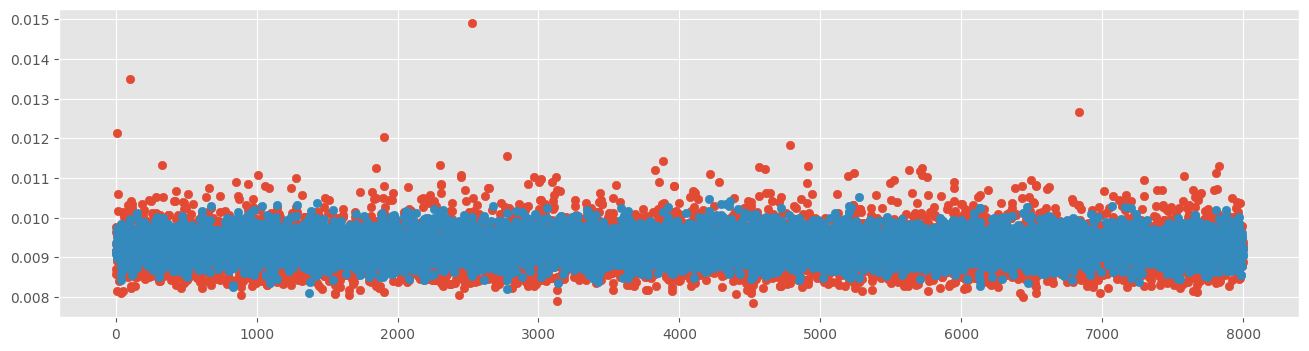

In [37]:
x = np.arange(8_000)
plt.figure(figsize=(16, 4))
plt.scatter(x, student_samples, label='Student-T')
plt.scatter(x, laplace_samples, label='Lalace')